In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("blight_tickets.csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_9680\3907193023.py:1: DtypeWarning: Columns (26,30,34,35,36,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("blight_tickets.csv")


In [3]:
df.head()

,ObjectId,Ticket ID,Ticket Number,Address,Ordinance Law,Ordinance Description,Disposition,Agency Name,Inspector Name,Ticket Issued Date,...,Street Number,Street Prefix,Street Name,Street Type,Parcel ID,Address ID,Longitude,Latitude,x,y
0,1,19939,05002662DAH,660 WOODWARD AVE,9-1-36(a),Failure of owner to obtain certificate of comp...,Responsible by Default,"Buildings, Safety Engineering & Env Department",Joseph Otis,2005-02-01,...,660.0,NaN,Woodward,Ave,01004105.,348114.0,-83.045282,42.330924,-9.244558e+06,5.210680e+06
1,2,19940,05000305DAH,18600 PREVOST,22-2-22,Bulk solid waste deposited more than 24 hours ...,Not responsible by Dismissal,BSEED Environmental Affairs,Lillett Williamson,2005-01-31,...,18600.0,NaN,Prevost,St,22055135.,62181.0,-83.203645,42.426882,-9.262187e+06,5.225140e+06
2,3,19942,05000306DAH,18492 PREVOST,22-2-22,Bulk solid waste deposited more than 24 hours ...,Not responsible by Dismissal,BSEED Environmental Affairs,Lillett Williamson,2005-01-31,...,18492.0,NaN,Prevost,St,22055131.,62189.0,-83.203609,42.426252,-9.262183e+06,5.225045e+06
3,4,19944,05004769DAH,15450 SCHAEFER HWY,9-1-103(C),Removal of snow and ice from sidewalks,Responsible by Admission,Health Department,Leah Jones,2005-01-28,...,15450.0,NaN,Schaefer,Hwy,22029963-72,452485.0,-83.178891,42.404445,-9.259432e+06,5.221757e+06
4,5,19945,05000307DAH,18261 FORRER,22-2-22,Bulk solid waste deposited more than 24 hours ...,Not responsible by Dismissal,BSEED Environmental Affairs,Lillett Williamson,2005-01-31,...,18261.0,NaN,Forrer,St,22054318.,62218.0,-83.202791,42.424065,-9.262092e+06,5.224716e+06


In [4]:
df.shape

(899283, 50)

In [5]:
df.columns

Index(['ObjectId', 'Ticket ID', 'Ticket Number', 'Address', 'Ordinance Law',
       'Ordinance Description', 'Disposition', 'Agency Name', 'Inspector Name',
       'Ticket Issued Date', 'Ticket Issued Time', 'Hearing Date',
       'Hearing Time', 'Judgement Date', 'Payment Date', 'Ticket Updated At',
       'Fine Amount', 'Admin Fee', 'State Fee', 'Late Fee', 'Discount Amount',
       'Clean Up Cost', 'Judgement Amount', 'Payment Amount', 'Balance Due',
       'Payment Status', 'Collection Status', 'Property Owner ID',
       'Property Owner Name', 'Property Owner Address',
       'Property Owner Street Number', 'Property Owner Street Name',
       'Property Owner City', 'Property Owner State',
       'Property Owner Zip Code', 'Property Owner Non US Address',
       'Property Owner Country', 'Neighborhood', 'Council District',
       'Zip Code', 'Street Number', 'Street Prefix', 'Street Name',
       'Street Type', 'Parcel ID', 'Address ID', 'Longitude', 'Latitude', 'x',
       'y'],


In [6]:
df.dtypes

ObjectId                           int64
Ticket ID                          int64
Ticket Number                     object
Address                           object
Ordinance Law                     object
Ordinance Description             object
Disposition                       object
Agency Name                       object
Inspector Name                    object
Ticket Issued Date                object
Ticket Issued Time                object
Hearing Date                      object
Hearing Time                      object
Judgement Date                    object
Payment Date                      object
Ticket Updated At                 object
Fine Amount                      float64
Admin Fee                          int64
State Fee                          int64
Late Fee                         float64
Discount Amount                  float64
Clean Up Cost                    float64
Judgement Amount                 float64
Payment Amount                   float64
Balance Due     

# removing waste columns

In [7]:
drop_cols = [
    # only ID/tracking columns
    'ObjectId', 'Ticket Number', 'Property Owner ID', 'Parcel ID', 'Address ID',

    # high-cardinality raw text
    'Property Owner Name','Inspector Name',

    # time in hours so not needed
    'Ticket Issued Time','Hearing Time',

    'Clean Up Cost'
]

df = df.drop(columns=drop_cols, errors='ignore')

print(df.shape)
print(df.columns)

(899283, 40)
Index(['Ticket ID', 'Address', 'Ordinance Law', 'Ordinance Description',
       'Disposition', 'Agency Name', 'Ticket Issued Date', 'Hearing Date',
       'Judgement Date', 'Payment Date', 'Ticket Updated At', 'Fine Amount',
       'Admin Fee', 'State Fee', 'Late Fee', 'Discount Amount',
       'Judgement Amount', 'Payment Amount', 'Balance Due', 'Payment Status',
       'Collection Status', 'Property Owner Address',
       'Property Owner Street Number', 'Property Owner Street Name',
       'Property Owner City', 'Property Owner State',
       'Property Owner Zip Code', 'Property Owner Non US Address',
       'Property Owner Country', 'Neighborhood', 'Council District',
       'Zip Code', 'Street Number', 'Street Prefix', 'Street Name',
       'Street Type', 'Longitude', 'Latitude', 'x', 'y'],
      dtype='object')


In [8]:
# address analysis
df[['Property Owner Street Number', 'Property Owner Street Name',
       'Property Owner City', 'Property Owner State',
       'Property Owner Zip Code', 'Property Owner Non US Address',
       'Property Owner Country','Address','Property Owner Address',]]

,Property Owner Street Number,Property Owner Street Name,Property Owner City,Property Owner State,Property Owner Zip Code,Property Owner Non US Address,Property Owner Country,Address,Property Owner Address
0,660,WOODWARD,DETROIT,MI,48226,NaN,NaN,660 WOODWARD AVE,660 WOODWARD
1,18600,PREVOST,DETROIT,MI,48235,NaN,NaN,18600 PREVOST,18600 PREVOST
2,16188,PARKSIDE,DETROIT,MI,48221,NaN,NaN,18492 PREVOST,16188 PARKSIDE
3,15450,SCHAFER,DETROIT,MI,48227,NaN,NaN,15450 SCHAEFER HWY,15450 SCHAFER
4,18261,FORRER,DETROIT,MI,48235,NaN,NaN,18261 FORRER,18261 FORRER
...,...,...,...,...,...,...,...,...,...
899278,15430,FENKELL,DETROIT,MI,48227,NaN,NaN,15310 GREENFIELD,15430 FENKELL
899279,43579,NORTH TIMBERVIEW DRIVE,BELLEVILLE,MI,48111,NaN,NaN,13110 MENDOTA,43579 NORTH TIMBERVIEW DRIVE
899280,18601,WALTHAM,DETROIT,MI,48205,NaN,NaN,18601 WALTHAM,18601 WALTHAM
899281,15430,FENKELL,DETROIT,MI,48227,NaN,NaN,15310 GREENFIELD,15430 FENKELL


In [9]:
df['Property Owner City'].value_counts()

Property Owner City
DETROIT                          376795
Detroit                           89428
SOUTHFIELD                        35323
DEARBORN                          16108
DETROIT                            9089
                                  ...  
MT CLEMONS                            1
ZHONGHE DIST. NEW TAIPEI CITY         1
FARMINGTON HILLS, MI                  1
LITTLEROCK                            1
KADERA RABCG                          1
Name: count, Length: 13478, dtype: int64

In [10]:
# removing problem of small and capital letters
cols_to_upper = ['Property Owner City', 'Property Owner State', 'Neighborhood','Street Prefix','Street Name',"Street Type"]

for col in cols_to_upper:
    df[col] = df[col].str.upper()

In [11]:
df = df.drop(columns=['Property Owner Non US Address'], errors='ignore')

In [12]:
df.isnull().sum().sort_values(ascending=False)

Property Owner Country          893714
Street Prefix                   792937
Payment Date                    672366
Collection Status               667966
x                               198024
y                               198024
Street Type                      36574
Zip Code                         18182
Disposition                       6945
Judgement Date                    6940
Property Owner State              6018
Property Owner Zip Code           5558
Property Owner City               5555
Neighborhood                      5252
Council District                  5136
Street Number                     5066
Street Name                       3823
Longitude                         3823
Latitude                          3823
Payment Status                     432
Property Owner Street Name         144
Address                             65
Property Owner Street Number        33
Late Fee                            11
Judgement Amount                     9
Balance Due              

In [13]:
# dropping bcz 90 percent is empty
df = df.drop(columns=['Property Owner Country', 'Street Prefix'], errors='ignore')

In [14]:
df['Neighborhood'].value_counts(dropna=False)

Neighborhood
WARRENDALE          32026
BAGLEY              21429
MIDWEST             20532
BRIGHTMOOR          20094
BARTON-MCFARLAND    18257
                    ...  
STATE FAIR             40
BREWSTER HOMES         33
DOUGLASS               21
WATERWORKS PARK        15
BELLE ISLE             11
Name: count, Length: 206, dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899283 entries, 0 to 899282
Data columns (total 37 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Ticket ID                     899283 non-null  int64  
 1   Address                       899218 non-null  object 
 2   Ordinance Law                 899281 non-null  object 
 3   Ordinance Description         899281 non-null  object 
 4   Disposition                   892338 non-null  object 
 5   Agency Name                   899283 non-null  object 
 6   Ticket Issued Date            899283 non-null  object 
 7   Hearing Date                  899282 non-null  object 
 8   Judgement Date                892343 non-null  object 
 9   Payment Date                  226917 non-null  object 
 10  Ticket Updated At             899283 non-null  object 
 11  Fine Amount                   899281 non-null  float64
 12  Admin Fee                     899283 non-nul

# address / location analysis

In [16]:
df[['Longitude','Latitude', 'x', 'y']]

,Longitude,Latitude,x,y
0,-83.045282,42.330924,-9.244558e+06,5.210680e+06
1,-83.203645,42.426882,-9.262187e+06,5.225140e+06
2,-83.203609,42.426252,-9.262183e+06,5.225045e+06
3,-83.178891,42.404445,-9.259432e+06,5.221757e+06
4,-83.202791,42.424065,-9.262092e+06,5.224716e+06
...,...,...,...,...
899278,-83.198325,42.401990,NaN,NaN
899279,-83.164027,42.383751,NaN,NaN
899280,-82.994993,42.431200,NaN,NaN
899281,-83.198325,42.401990,NaN,NaN


In [17]:
df['Longitude'].corr(df['x'])

np.float64(1.0)

In [18]:
df['Latitude'].corr(df['y'])

np.float64(0.9999999326725174)

In [19]:
# x,y are correlated with long and latitude, and have too much null value, dropping them
df = df.drop(columns=['x', 'y'], errors='ignore')

In [20]:
df[['Property Owner Street Number', 'Property Owner Street Name',
       'Property Owner City', 'Property Owner State',
       'Property Owner Zip Code']].isnull().sum()

Property Owner Street Number      33
Property Owner Street Name       144
Property Owner City             5555
Property Owner State            6018
Property Owner Zip Code         5558
dtype: int64

In [21]:
df = df.drop(columns=['Property Owner Street Number', 'Property Owner Street Name'], errors='ignore')

# owner related features

In [22]:
df['is_out_of_state_owner'] = df['Property Owner State'] != 'MI'

In [23]:
df['owner_lives_in_detroit'] = df['Property Owner City'].str.strip() == 'DETROIT'

In [24]:
df['owner_lives_at_violation_property'] = (
    df['Property Owner Address'].str.upper().str.strip() ==
    df['Address'].str.upper().str.strip()
)

In [25]:
df = df.drop(columns=['Property Owner State','Property Owner City','Property Owner Zip Code','Property Owner Address'], errors='ignore')

In [26]:
# high-cardinality, essential info already captured by Neighborhood, Zip Code, Longitude/Latitude
df = df.drop(columns=['Street Number', 'Street Name', 'Street Type','Address'], errors='ignore')

In [27]:
df[['Neighborhood', 'Council District', 'Zip Code',
       'Longitude', 'Latitude', 'is_out_of_state_owner',
       'owner_lives_in_detroit', 'owner_lives_at_violation_property']]

,Neighborhood,Council District,Zip Code,Longitude,Latitude,is_out_of_state_owner,owner_lives_in_detroit,owner_lives_at_violation_property
0,DOWNTOWN,6.0,48226.0,-83.045282,42.330924,False,True,False
1,COLLEGE PARK,2.0,48235.0,-83.203645,42.426882,False,True,True
2,COLLEGE PARK,2.0,48235.0,-83.203609,42.426252,False,True,False
3,BETHUNE COMMUNITY,7.0,48227.0,-83.178891,42.404445,False,True,False
4,COLLEGE PARK,2.0,48235.0,-83.202791,42.424065,False,True,True
...,...,...,...,...,...,...,...,...
899278,BELMONT,2.0,48227,-83.198325,42.401990,False,True,False
899279,GRAND RIVER-I96,7.0,48238,-83.164027,42.383751,False,False,False
899280,VON STEUBEN,3.0,48205,-82.994993,42.431200,False,True,True
899281,BELMONT,2.0,48227,-83.198325,42.401990,False,True,False


In [28]:
(df[['Neighborhood', 'Council District', 'Zip Code', 'Longitude', 'Latitude',
     'is_out_of_state_owner', 'owner_lives_in_detroit']].isnull().sum() / len(df) * 100)

Neighborhood              0.584021
Council District          0.571122
Zip Code                  2.021833
Longitude                 0.425116
Latitude                  0.425116
is_out_of_state_owner     0.000000
owner_lives_in_detroit    0.000000
dtype: float64

In [29]:
df = df.dropna(subset=['Neighborhood', 'Council District', 'Zip Code', 'Longitude', 'Latitude'])
print(df.shape)

(879568, 28)


In [30]:
df = df.dropna(subset=['Ticket ID', 'Ordinance Law', 'Ordinance Description', 'Disposition',
       'Agency Name',])

lets build target column

In [31]:
df['Hearing Date'] = pd.to_datetime(df['Hearing Date'], errors='coerce')
df['Payment Date'] = pd.to_datetime(df['Payment Date'], errors='coerce')

def get_compliance(row):
    if 'Not responsible' in str(row['Disposition']):
        return None
    if pd.isna(row['Payment Date']):
        return 0
    days_late = (row['Payment Date'] - row['Hearing Date']).days
    if days_late <= 30:
        return 1
    return 0

df['compliance'] = df.apply(get_compliance, axis=1)
print(df['compliance'].value_counts(dropna=False))

compliance
0.0    477890
NaN    306652
1.0     88190
Name: count, dtype: int64


In [32]:
df_train = df[df['compliance'].notna()].copy()
print(df_train.shape)

(566080, 29)


In [33]:
leakage_cols = ['Payment Date', 'Payment Amount', 'Payment Status',
                 'Balance Due', 'Collection Status', 'Judgement Date', 'Ticket Updated At']
df_train = df_train.drop(columns=leakage_cols, errors='ignore')
print(df_train.columns.tolist())

['Ticket ID', 'Ordinance Law', 'Ordinance Description', 'Disposition', 'Agency Name', 'Ticket Issued Date', 'Hearing Date', 'Fine Amount', 'Admin Fee', 'State Fee', 'Late Fee', 'Discount Amount', 'Judgement Amount', 'Neighborhood', 'Council District', 'Zip Code', 'Longitude', 'Latitude', 'is_out_of_state_owner', 'owner_lives_in_detroit', 'owner_lives_at_violation_property', 'compliance']


In [34]:
df_train[["Ordinance Law", 'Ordinance Description', 'Disposition', 'Agency Name']]

,Ordinance Law,Ordinance Description,Disposition,Agency Name
0,9-1-36(a),Failure of owner to obtain certificate of comp...,Responsible by Default,"Buildings, Safety Engineering & Env Department"
3,9-1-103(C),Removal of snow and ice from sidewalks,Responsible by Admission,Health Department
6,9-1-36(a),Failure of owner to obtain certificate of comp...,Responsible by Determination,"Buildings, Safety Engineering & Env Department"
9,9-1-103(C),Removal of snow and ice from sidewalks,Responsible by Admission,Health Department
10,9-1-36(a),Failure of owner to obtain certificate of comp...,Responsible by Default,"Buildings, Safety Engineering & Env Department"
...,...,...,...,...
897001,8-15-104,Excessive weeds or plant growth one- or two-fa...,Responsible by Admission,BSEED Environmental Affairs
897014,42-2-50,Violation of time limit for approved container...,Responsible by Admission,BSEED Environmental Affairs
897297,8-15-104,Excessive weeds or plant growth one- or two-fa...,Responsible by Admission,BSEED Environmental Affairs
897341,42-2-97(b),Allowing bulk solid waste to lie or accumulate...,Responsible by Admission,BSEED Environmental Affairs


In [35]:
print(df_train['Ordinance Law'].nunique())
print(df_train['Ordinance Description'].nunique())

449
392


In [36]:
df_train['Ordinance Law'].value_counts()

Ordinance Law
9-1-36(a)             65810
8-15-104              46390
42-2-97(b)            36242
9-1-104               35522
8-15-35               31950
                      ...  
61-83.0100/32.0066        1
8-15-403                  1
42-2-75                   1
8-15-217                  1
8-15-402                  1
Name: count, Length: 449, dtype: int64

In [37]:
df_train['Ordinance Description'].value_counts()

Ordinance Description
Excessive weeds or plant growth one- or two-family dwelling or commercial Building                                 81912
Failure of owner to obtain certificate of compliance                                                               71917
Allowing bulk solid waste to lie or accumulate on or about the premises                                            65219
Failure to obtain certificate of registration for rental property                                                  43025
Certificate of Compliance required; vioilation for failure to obtain                                               31950
                                                                                                                   ...  
Unsuitable or inadequate facilities for food preparation one- or two- family dwelling or building                      1
FAILURE TO SUBMIT TIMELY FUGITIVE DUST PLAN FOR COMMUNITY ESTABLISHMENT ACTIVITY                                       1
Failure of

In [38]:
# lets check correlation with compliance
df_train.groupby('Ordinance Law')['compliance'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
Ordinance Law,,
9-1-471,1.0,1
9-1-381,1.0,1
4-4-163,1.0,1
9-1-412,1.0,1
22-2-48(b),1.0,2
...,...,...
9-1-443(b),0.0,2
9-1-441,0.0,7
9-1-442,0.0,12


In [39]:
df_train.groupby('Ordinance Description')['compliance'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
Ordinance Description,,
Defective basement hatchway(s) one- or two-family dwelling or commercial building,1.0,1
Temporary Signs (90 day Single-tenant Residential),1.0,3
Owner as listed in Wayne County Registar of Deeds unless written intrument to the contrary is presented,1.0,1
Open Storage/ Residential/ Debris (R4),1.0,1
Failure to maintain skirting for exterior opening(s) one- or two-family dwelling or commercial building,1.0,1
...,...,...
Failed to comply with other land use or procedural requirements - Other unlawful storage(RESIDENTIAL),0.0,4
Advertising signs located in right of way,0.0,7
A violation of R336.1301 of the Michigan Administrative code for Scrap Processors allowing visible emissions,0.0,3


In [40]:
df_train = df_train.drop(columns=['Ordinance Law'])

In [41]:
# Ordinance Description bucket (top 20 + "Other")
top_desc = df_train['Ordinance Description'].value_counts().nlargest(20).index
df_train['Ordinance Description'] = df_train['Ordinance Description'].apply(
    lambda x: x if x in top_desc else 'Other'
)

In [42]:
df_train['Ticket Issued Date'] = pd.to_datetime(df_train['Ticket Issued Date'], errors='coerce')
df_train['Hearing Date'] = pd.to_datetime(df_train['Hearing Date'], errors='coerce')

df_train['days_to_hearing'] = (df_train['Hearing Date'] - df_train['Ticket Issued Date']).dt.days

df_train = df_train.drop(columns=['Ticket Issued Date', 'Hearing Date'])

In [43]:
print(df_train[['days_to_hearing']].describe())

       days_to_hearing
count    566061.000000
mean         72.277613
std         201.006178
min      -65714.000000
25%          27.000000
50%          52.000000
75%          90.000000
max       73085.000000


Numeric (continuous): Fine Amount, Admin Fee, State Fee, Late Fee, Discount Amount, Judgement Amount, Longitude, Latitude, days_to_hearing

Categorical (text): Ordinance Description, Disposition, Agency Name, Neighborhood, Council District, Zip Code

Boolean: is_out_of_state_owner, owner_lives_in_detroit, owner_lives_at_violation_property

Target: compliance

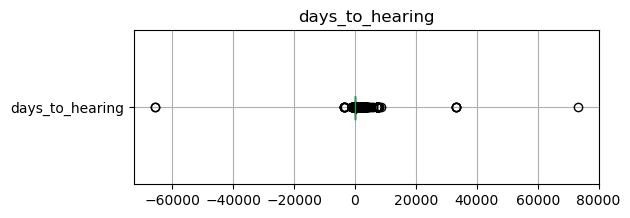

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 2))
df_train.boxplot(column='days_to_hearing', vert=False)
plt.title('days_to_hearing')
plt.show()

### days to hearing problem

In [45]:
print((df_train['days_to_hearing'] < 0).sum())
df_train[df_train['days_to_hearing'] < 0][['days_to_hearing']].describe()

440


,days_to_hearing
count,440.000000
mean,-510.238636
std,4430.919258
min,-65714.000000
25%,-282.000000
50%,-177.500000
75%,-10.000000
max,-1.000000


In [46]:
print((df_train['days_to_hearing'] > 1000).sum())
df_train[df_train['days_to_hearing'] > 1000][['days_to_hearing']].describe()

152


,days_to_hearing
count,152.000000
mean,4358.842105
std,7688.287066
min,1004.000000
25%,1332.000000
50%,2596.000000
75%,3708.000000
max,73085.000000


In [47]:
total = len(df_train)
negative_pct = (df_train['days_to_hearing'] < 0).sum() / total * 100
extreme_pct = (df_train['days_to_hearing'] > 1000).sum() / total * 100

print(f"Negative: {negative_pct:.2f}%")
print(f"Extreme (>1000 days): {extreme_pct:.2f}%")

Negative: 0.08%
Extreme (>1000 days): 0.03%


In [48]:
df_train = df_train[(df_train['days_to_hearing'] >= 0) & (df_train['days_to_hearing'] <= 1000)]

print(df_train.shape)
print(df_train['days_to_hearing'].describe())

(565469, 20)
count    565469.000000
mean         71.578635
std          64.927715
min           0.000000
25%          27.000000
50%          52.000000
75%          90.000000
max        1000.000000
Name: days_to_hearing, dtype: float64


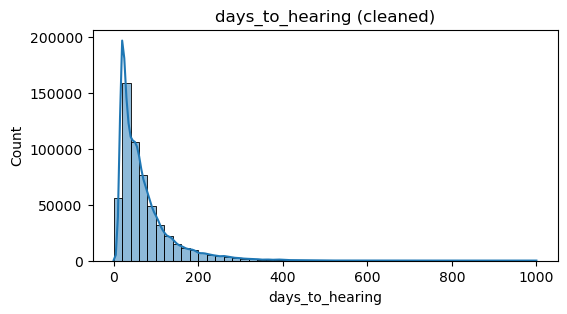

In [49]:
plt.figure(figsize=(6,3))
sns.histplot(df_train['days_to_hearing'], kde=True, bins=50)
plt.title('days_to_hearing (cleaned)')
plt.show()

In [50]:
from scipy.stats import skew
print(skew(df_train['days_to_hearing']))

2.5273090438194936


In [51]:
# checking if log transform helps
df_train['days_to_hearing_log'] = np.log1p(df_train['days_to_hearing'])

print("Original skewness:", skew(df_train['days_to_hearing']))
print("Log-transformed skewness:", skew(df_train['days_to_hearing_log']))

Original skewness: 2.5273090438194936
Log-transformed skewness: 0.33085741181508643


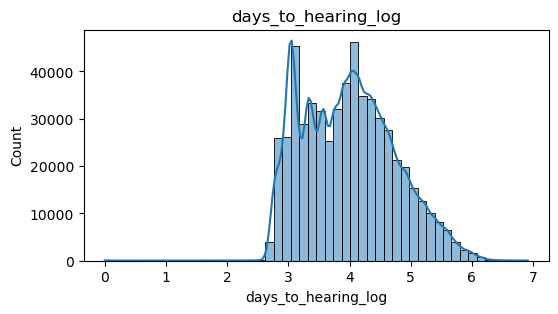

In [52]:
plt.figure(figsize=(6,3))
sns.histplot(df_train['days_to_hearing_log'], kde=True, bins=50)
plt.title('days_to_hearing_log')
plt.show()

In [53]:
# xgboost doesnt care about skew, dropping the log version
df_train = df_train.drop(columns=['days_to_hearing_log'], errors='ignore')

In [54]:
numeric_cols = ['Fine Amount', 'Admin Fee', 'State Fee', 'Late Fee', 'Discount Amount', 'Judgement Amount']

for col in numeric_cols:
    print(f"--- {col} ---")
    print(df_train[col].describe())

--- Fine Amount ---
count    565469.000000
mean        291.027918
std         399.428790
min           1.000000
25%         100.000000
50%         250.000000
75%         250.000000
max       10000.000000
Name: Fine Amount, dtype: float64
--- Admin Fee ---
count    565469.000000
mean         19.991618
std           0.409364
min           0.000000
25%          20.000000
50%          20.000000
75%          20.000000
max          20.000000
Name: Admin Fee, dtype: float64
--- State Fee ---
count    565469.000000
mean          9.995809
std           0.204682
min           0.000000
25%          10.000000
50%          10.000000
75%          10.000000
max          10.000000
Name: State Fee, dtype: float64
--- Late Fee ---
count    565462.000000
mean         26.721167
std          39.786606
min          -1.000000
25%           5.000000
50%          20.000000
75%          25.000000
max        1000.000000
Name: Late Fee, dtype: float64
--- Discount Amount ---
count    565469.000000
mean          1

In [55]:
print(df_train['Fine Amount'].quantile([0.99, 0.999]))
print(df_train['Judgement Amount'].quantile([0.99, 0.999]))

0.990    2000.0
0.999    3500.0
Name: Fine Amount, dtype: float64
0.990    2230.0
0.999    3880.0
Name: Judgement Amount, dtype: float64


In [56]:
numeric_cols = ['Fine Amount', 'Admin Fee', 'State Fee', 'Late Fee',
                 'Discount Amount', 'Judgement Amount','days_to_hearing']

corr_matrix = df_train[numeric_cols].corr()
print(corr_matrix)

                  Fine Amount  Admin Fee  State Fee  Late Fee  \
Fine Amount          1.000000  -0.005338  -0.005338  0.955913   
Admin Fee           -0.005338   1.000000   1.000000  0.013286   
State Fee           -0.005338   1.000000   1.000000  0.013286   
Late Fee             0.955913   0.013286   0.013286  1.000000   
Discount Amount      0.113910   0.001863   0.001863 -0.053259   
Judgement Amount     0.957519   0.015780   0.015780  0.934910   
days_to_hearing     -0.016869  -0.013676  -0.013676 -0.023969   

                  Discount Amount  Judgement Amount  days_to_hearing  
Fine Amount              0.113910          0.957519        -0.016869  
Admin Fee                0.001863          0.015780        -0.013676  
State Fee                0.001863          0.015780        -0.013676  
Late Fee                -0.053259          0.934910        -0.023969  
Discount Amount          1.000000          0.069638         0.028294  
Judgement Amount         0.069638          1.000000  

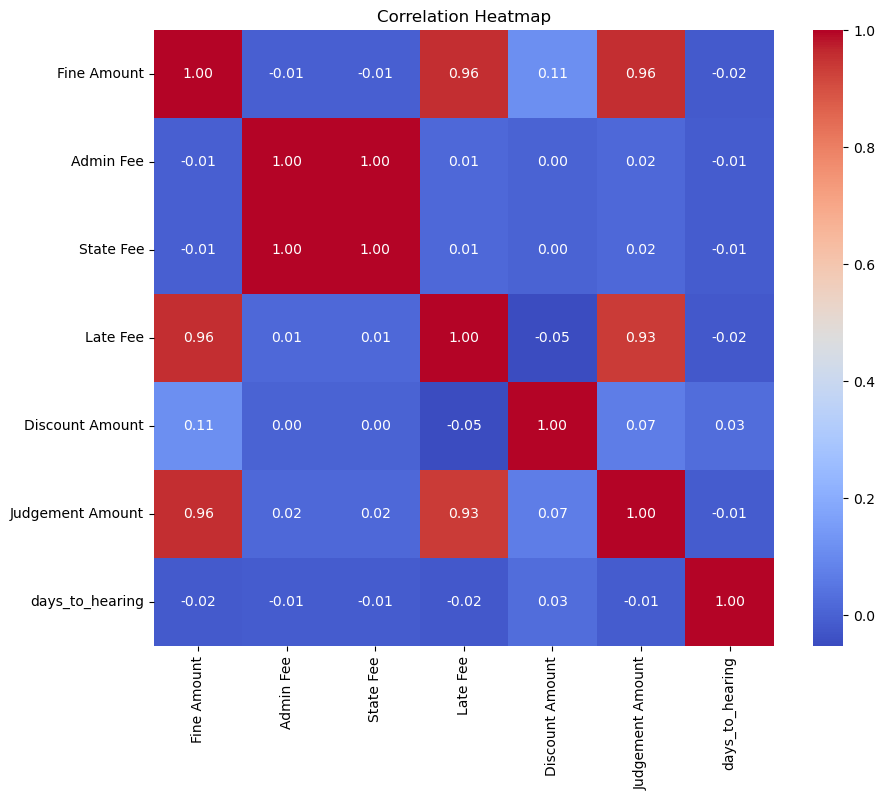

In [57]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [58]:
# Fine Amount, Late Fee, Judgement Amount are basically the same info (corr ~0.98)
# Admin Fee / State Fee also duplicate each other, dropping the redundant ones
df_train = df_train.drop(columns=['State Fee', 'Judgement Amount','Late Fee'], errors='ignore')

## categorical encoding

In [59]:
# sab teeno one-hot encode karo
df_train = pd.get_dummies(df_train, columns=['Ordinance Description', 'Disposition', 'Agency Name'], drop_first=True)

print(df_train.shape)
print(df_train.dtypes)

(565469, 49)
Ticket ID                                                                                                                                                                                               int64
Fine Amount                                                                                                                                                                                           float64
Admin Fee                                                                                                                                                                                               int64
Discount Amount                                                                                                                                                                                       float64
Neighborhood                                                                                                                                                       

In [60]:
df_train.select_dtypes(include='object').columns

Index(['Neighborhood', 'Zip Code'], dtype='object')

In [61]:
print(df_train['Neighborhood'].nunique())
print(df_train['Zip Code'].nunique())

205
167


In [62]:
df_train = df_train.drop(columns=['Zip Code'])  # as latitude and longitude covers it

In [63]:
print(df_train['Neighborhood'].value_counts())

Neighborhood
WARRENDALE           22536
BAGLEY               13994
BARTON-MCFARLAND     12014
BRIGHTMOOR           11832
BETHUNE COMMUNITY    11366
                     ...  
STATE FAIR              24
ROUGE PARK              23
DOUGLASS                15
WATERWORKS PARK          8
BELLE ISLE               1
Name: count, Length: 205, dtype: int64


In [64]:
top_neigh = df_train['Neighborhood'].value_counts().nlargest(35).index
df_train['Neighborhood'] = df_train['Neighborhood'].apply(lambda x: x if x in top_neigh else 'Other')
print(df_train['Neighborhood'].nunique())

36


In [65]:
df_train = pd.get_dummies(df_train, columns=['Neighborhood'], drop_first=True)

print(df_train.select_dtypes(include='object').columns)
print(df_train.shape)

Index([], dtype='object')
(565469, 82)


# train test split on basis of time

In [66]:
# extracting year from ticket id date, will use this for the split
df['Ticket Issued Date'] = pd.to_datetime(df['Ticket Issued Date'], errors='coerce')
df['ticket_year'] = df['Ticket Issued Date'].dt.year

year_lookup = df[['Ticket ID', 'ticket_year']]

In [67]:
# merging ticket year with ticket id as common key
df_train = df_train.merge(year_lookup, on='Ticket ID', how='left')

print(df_train['ticket_year'].value_counts().sort_index())

ticket_year
2004.0        8
2005.0    19115
2006.0    19892
2007.0    18314
2008.0    19833
2009.0    15531
2010.0    10587
2011.0     7439
2012.0     5894
2013.0     5476
2014.0     8792
2015.0    15199
2016.0    16659
2017.0    20788
2018.0    24420
2019.0    37972
2020.0    23989
2021.0    39222
2022.0    58606
2023.0    64703
2024.0    56489
2025.0    54859
2026.0    21682
Name: count, dtype: int64


In [68]:
print(df_train[df_train['ticket_year'] <= 2023].shape)
print(df_train[df_train['ticket_year'] > 2023].shape)

(432439, 83)
(133030, 83)


In [69]:
train_set = df_train[df_train['ticket_year'] <= 2023].copy()
val_set = df_train[df_train['ticket_year'] > 2023].copy()

print("Train:", train_set.shape)
print("Validation:", val_set.shape)
print("Train %:", len(train_set) / len(df_train) * 100)
print("Validation %:", len(val_set) / len(df_train) * 100)

Train: (432439, 83)
Validation: (133030, 83)
Train %: 76.47439559020918
Validation %: 23.52560440979081


In [70]:
drop_for_features = ['Ticket ID', 'ticket_year', 'compliance']

X_train = train_set.drop(columns=drop_for_features)
y_train = train_set['compliance']

X_val = val_set.drop(columns=drop_for_features)
y_val = val_set['compliance']

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(432439, 80) (432439,)
(133030, 80) (133030,)


# model training

In [71]:
print(X_train.isnull().sum().sort_values(ascending=False).head(20))

Fine Amount                                                                                                                                                                                           0
Admin Fee                                                                                                                                                                                             0
Discount Amount                                                                                                                                                                                       0
Council District                                                                                                                                                                                      0
Longitude                                                                                                                                                                                             0


In [72]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_val = X_val.dropna()
y_val = y_val.loc[X_val.index]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(432439, 80) (432439,)
(133030, 80) (133030,)


In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# logistic regression (baseline)

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc
)

In [75]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_val_scaled)
y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_pred_proba))

precision, recall, _ = precision_recall_curve(y_val, y_pred_proba)
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93    113544
         1.0       0.59      0.66      0.62     19486

    accuracy                           0.88    133030
   macro avg       0.76      0.79      0.77    133030
weighted avg       0.89      0.88      0.88    133030

ROC-AUC: 0.8491600388889695
PR-AUC: 0.6822857043038069


# xg boost

In [76]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # imbalance handle karne ke liye
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)
y_pred_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_val, y_pred_proba_xgb))

precision, recall, _ = precision_recall_curve(y_val, y_pred_proba_xgb)
pr_auc_xgb = auc(recall, precision)
print("PR-AUC:", pr_auc_xgb)

              precision    recall  f1-score   support

         0.0       0.94      0.91      0.93    113544
         1.0       0.57      0.67      0.61     19486

    accuracy                           0.88    133030
   macro avg       0.76      0.79      0.77    133030
weighted avg       0.89      0.88      0.88    133030

ROC-AUC: 0.855396150010024
PR-AUC: 0.6961921422651851


In [77]:
thresholds = np.arange(0.1, 0.9, 0.05)
for t in thresholds:
    y_pred_t = (y_pred_proba_xgb >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(y_val, y_pred_t)
    r = recall_score(y_val, y_pred_t)
    f1 = f1_score(y_val, y_pred_t)
    print(f"Threshold: {t:.2f} | Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")

Threshold: 0.10 | Precision: 0.152 | Recall: 0.996 | F1: 0.264
Threshold: 0.15 | Precision: 0.168 | Recall: 0.978 | F1: 0.287
Threshold: 0.20 | Precision: 0.196 | Recall: 0.938 | F1: 0.324
Threshold: 0.25 | Precision: 0.242 | Recall: 0.878 | F1: 0.380
Threshold: 0.30 | Precision: 0.301 | Recall: 0.823 | F1: 0.440
Threshold: 0.35 | Precision: 0.366 | Recall: 0.775 | F1: 0.497
Threshold: 0.40 | Precision: 0.448 | Recall: 0.724 | F1: 0.553
Threshold: 0.45 | Precision: 0.522 | Recall: 0.689 | F1: 0.594
Threshold: 0.50 | Precision: 0.570 | Recall: 0.668 | F1: 0.615
Threshold: 0.55 | Precision: 0.591 | Recall: 0.658 | F1: 0.623
Threshold: 0.60 | Precision: 0.601 | Recall: 0.652 | F1: 0.625
Threshold: 0.65 | Precision: 0.610 | Recall: 0.647 | F1: 0.628
Threshold: 0.70 | Precision: 0.621 | Recall: 0.638 | F1: 0.630
Threshold: 0.75 | Precision: 0.643 | Recall: 0.622 | F1: 0.632
Threshold: 0.80 | Precision: 0.689 | Recall: 0.587 | F1: 0.634
Threshold: 0.85 | Precision: 0.774 | Recall: 0.517 | F1

In [ ]:
best_threshold = 0.70  

y_pred_final = (y_pred_proba_xgb >= best_threshold).astype(int)
print(classification_report(y_val, y_pred_final))

              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94    113544
         1.0       0.62      0.64      0.63     19486

    accuracy                           0.89    133030
   macro avg       0.78      0.79      0.78    133030
weighted avg       0.89      0.89      0.89    133030



# over fitting check

In [79]:
y_pred_train = xgb_model.predict(X_train)
y_pred_proba_train = xgb_model.predict_proba(X_train)[:, 1]

print("=== TRAINING SET ===")
print(classification_report(y_train, y_pred_train))
print("ROC-AUC:", roc_auc_score(y_train, y_pred_proba_train))

print("\n=== VALIDATION SET ===")
print(classification_report(y_val, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_val, y_pred_proba_xgb))

=== TRAINING SET ===
              precision    recall  f1-score   support

         0.0       0.95      0.91      0.93    363876
         1.0       0.61      0.72      0.66     68563

    accuracy                           0.88    432439
   macro avg       0.78      0.82      0.80    432439
weighted avg       0.89      0.88      0.89    432439

ROC-AUC: 0.8919752104564759

=== VALIDATION SET ===
              precision    recall  f1-score   support

         0.0       0.94      0.91      0.93    113544
         1.0       0.57      0.67      0.61     19486

    accuracy                           0.88    133030
   macro avg       0.76      0.79      0.77    133030
weighted avg       0.89      0.88      0.88    133030

ROC-AUC: 0.855396150010024


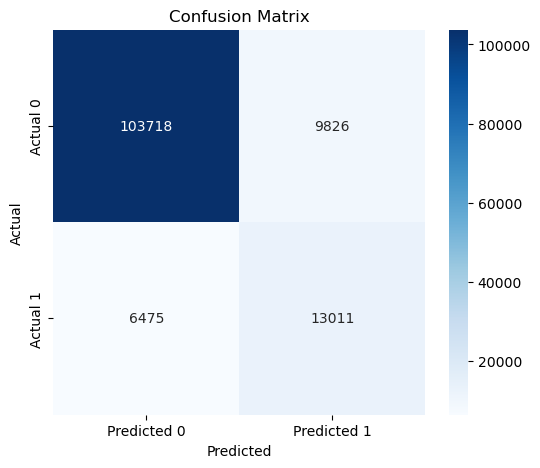

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# dollar effect

In [81]:
# False Positive rows nikaalo (actual non-compliant, predicted compliant)
fp_mask = (y_val == 0) & (y_pred_xgb == 1)
fp_indices = y_val[fp_mask].index

avg_fine_fp = X_val.loc[fp_indices, 'Fine Amount'].mean()
total_potential_loss = X_val.loc[fp_indices, 'Fine Amount'].sum()

print(f"False Positives count: {fp_mask.sum()}")
print(f"Average fine amount in FP cases: ${avg_fine_fp:.2f}")
print(f"Total potential missed revenue (validation set only): ${total_potential_loss:,.2f}")

False Positives count: 9826
Average fine amount in FP cases: $246.45
Total potential missed revenue (validation set only): $2,421,600.00


# shap

c:\Users\HP\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


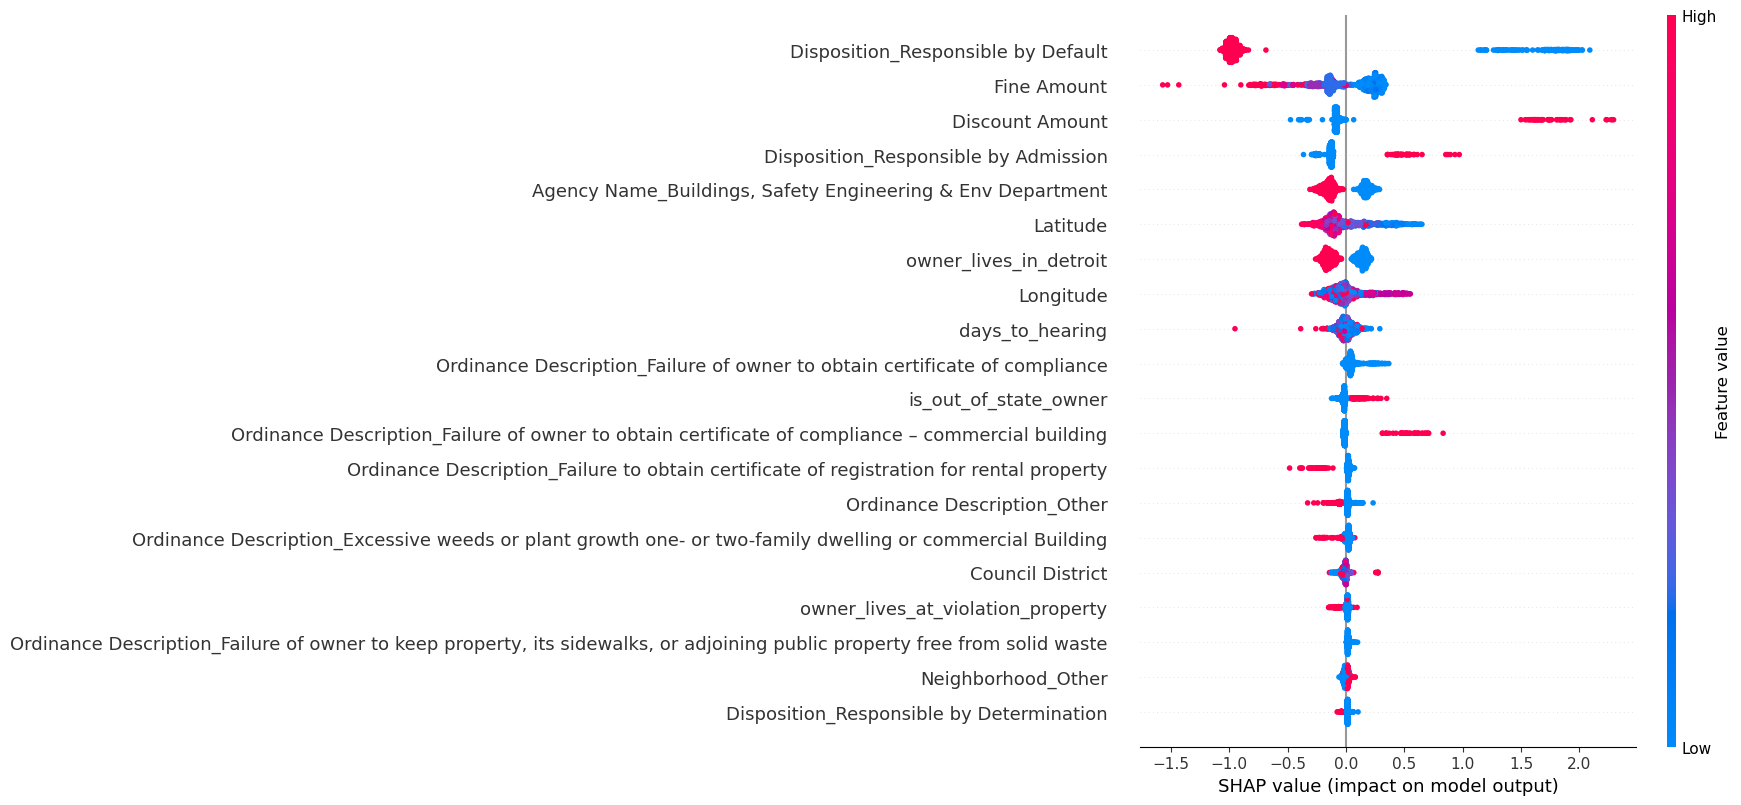

In [82]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val.sample(1000, random_state=42))  # sample lo speed ke liye

shap.summary_plot(shap_values, X_val.sample(1000, random_state=42))

# vif check

In [83]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_features = ['Fine Amount', 'Admin Fee', 'Discount Amount', 'Council District',
                     'Longitude', 'Latitude', 'days_to_hearing']

scaler2 = StandardScaler()
X_scaled = pd.DataFrame(
    scaler2.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index
)

vif_data = pd.DataFrame()
vif_data["feature"] = numeric_features
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled.values, i)
    for i in range(len(numeric_features))
]

print(vif_data.sort_values("VIF", ascending=False))

            feature       VIF
5          Latitude  2.198818
3  Council District  2.168044
4         Longitude  1.097189
2   Discount Amount  1.013848
0       Fine Amount  1.013646
6   days_to_hearing  1.003587
1         Admin Fee  1.000299


In [84]:
# Admin Fee had near-zero variance so VIF looked off before scaling, dropping it
X_train = X_train.drop(columns=['Admin Fee'], errors='ignore')
X_val = X_val.drop(columns=['Admin Fee'], errors='ignore')

xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss', random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
print("ROC-AUC:", roc_auc_score(y_val, y_pred_proba_xgb))

ROC-AUC: 0.8550570644659555


# trying smote vs class weighting

In [85]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: compliance
0.0    363876
1.0     68563
Name: count, dtype: int64
After SMOTE: compliance
0.0    363876
1.0    363876
Name: count, dtype: int64


In [86]:
xgb_model_smote = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    eval_metric='logloss', random_state=42
)
xgb_model_smote.fit(X_train_smote, y_train_smote)

y_pred_proba_smote = xgb_model_smote.predict_proba(X_val)[:, 1]

print("ROC-AUC with SMOTE:", roc_auc_score(y_val, y_pred_proba_smote))
precision, recall, _ = precision_recall_curve(y_val, y_pred_proba_smote)
print("PR-AUC with SMOTE:", auc(recall, precision))
# class weighting came out ahead of this, sticking with scale_pos_weight for the final model

ROC-AUC with SMOTE: 0.8452448458841824
PR-AUC with SMOTE: 0.6793358754550911


# light gbm comparison

In [87]:
import re
from lightgbm import LGBMClassifier

# lightgbm doesnt allow special characters in column names
X_train_lgb = X_train.copy()
X_val_lgb = X_val.copy()

X_train_lgb.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', c) for c in X_train_lgb.columns]
X_val_lgb.columns = X_train_lgb.columns

lgb_model = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42
)

lgb_model.fit(X_train_lgb, y_train)

y_pred_proba_lgb = lgb_model.predict_proba(X_val_lgb)[:, 1]

print(classification_report(y_val, (y_pred_proba_lgb >= best_threshold).astype(int)))
print("ROC-AUC:", roc_auc_score(y_val, y_pred_proba_lgb))

precision_lgb, recall_lgb, _ = precision_recall_curve(y_val, y_pred_proba_lgb)
print("PR-AUC:", auc(recall_lgb, precision_lgb))

[LightGBM] [Info] Number of positive: 68563, number of negative: 363876
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058105 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 977
[LightGBM] [Info] Number of data points in the train set: 432439, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.158550 -> initscore=-1.669060
[LightGBM] [Info] Start training from score -1.669060
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
              precision    recall  f1-score   support

         0.

all three models (logistic regression, xgboost, lightgbm) land within ~0.003 ROC-AUC of each other,
so the feature set is basically at its ceiling. going with xgboost as the final model since it had the
best PR-AUC.

# saving the final model

In [88]:
import joblib

joblib.dump(xgb_model, 'blight_compliance_model.pkl')
joblib.dump(X_train.columns.tolist(), 'model_features.pkl')
joblib.dump(best_threshold, 'model_threshold.pkl')

print("saved")

saved
